# SVM with RBF Kernel — Raw Data
## Wisconsin Breast Cancer Dataset
### Pipeline: Load → 80/20 Split → Scale → Train SVM(rbf) → Blue Visualizations

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
sns.set_palette('Blues')
plt.rcParams['axes.prop_cycle']=plt.cycler(color=plt.cm.Blues(np.linspace(0.3,0.9,8)))
import warnings;warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('../../data.csv')
if 'Unnamed: 32' in df.columns: df=df.drop(['id','Unnamed: 32'],axis=1)
else: df=df.drop(['id'],axis=1)
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})
print(f"Class distribution:\n{df['diagnosis'].value_counts()}")

Class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [3]:
X=df.drop('diagnosis',axis=1);y=df['diagnosis']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler();X_train_scaled=scaler.fit_transform(X_train);X_test_scaled=scaler.transform(X_test)

In [4]:
svm_rbf=SVC(kernel='rbf',probability=True,random_state=42).fit(X_train_scaled,y_train)
y_pred=svm_rbf.predict(X_test_scaled);y_proba=svm_rbf.predict_proba(X_test_scaled)[:,1]
print("Model trained on RAW data.")

Model trained on RAW data.


In [5]:
acc=accuracy_score(y_test,y_pred);prec=precision_score(y_test,y_pred);rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred);cm=confusion_matrix(y_test,y_pred);tn,fp,fn,tp=cm.ravel()
spec=tn/(tn+fp);auc=roc_auc_score(y_test,y_proba)
print(f"Acc:{acc:.4f} Prec:{prec:.4f} Rec:{rec:.4f} F1:{f1:.4f} Spec:{spec:.4f} AUC:{auc:.4f}\nCM:\n{cm}")

Acc:0.9737 Prec:1.0000 Rec:0.9286 F1:0.9630 Spec:1.0000 AUC:0.9947
CM:
[[72  0]
 [ 3 39]]


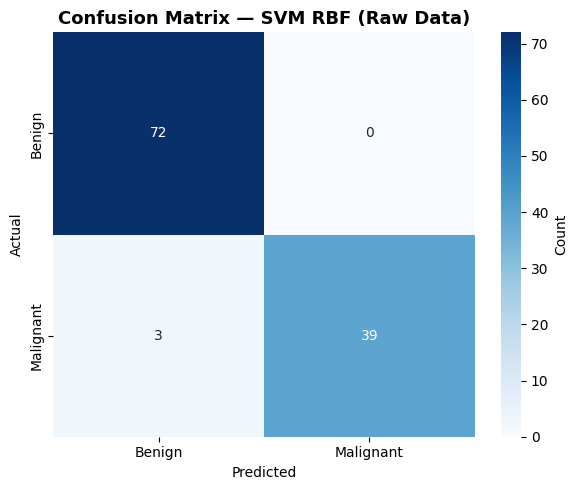

In [6]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Benign','Malignant'],yticklabels=['Benign','Malignant'],cbar_kws={'label':'Count'})
plt.title('Confusion Matrix — SVM RBF (Raw Data)',fontsize=13,fontweight='bold')
plt.xlabel('Predicted');plt.ylabel('Actual');plt.tight_layout();plt.show()

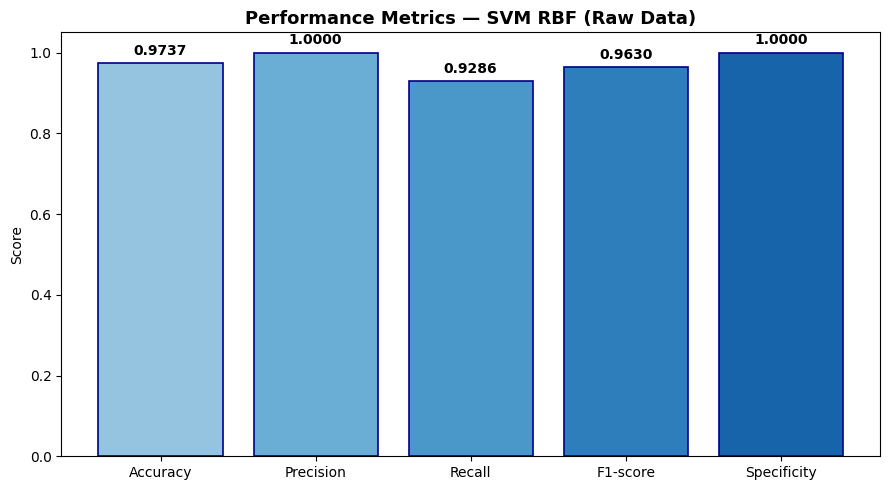

In [7]:
n=['Accuracy','Precision','Recall','F1-score','Specificity'];v=[acc,prec,rec,f1,spec];c=plt.cm.Blues([0.4,0.5,0.6,0.7,0.8])
plt.figure(figsize=(9,5))
bars=plt.bar(n,v,color=c,edgecolor='darkblue',linewidth=1.2)
plt.ylim(0,1.05);plt.title('Performance Metrics — SVM RBF (Raw Data)',fontsize=13,fontweight='bold');plt.ylabel('Score')
for b,v in zip(bars,v): plt.text(b.get_x()+b.get_width()/2,b.get_height()+0.02,f'{v:.4f}',ha='center',fontsize=10,fontweight='bold')
plt.tight_layout();plt.show()

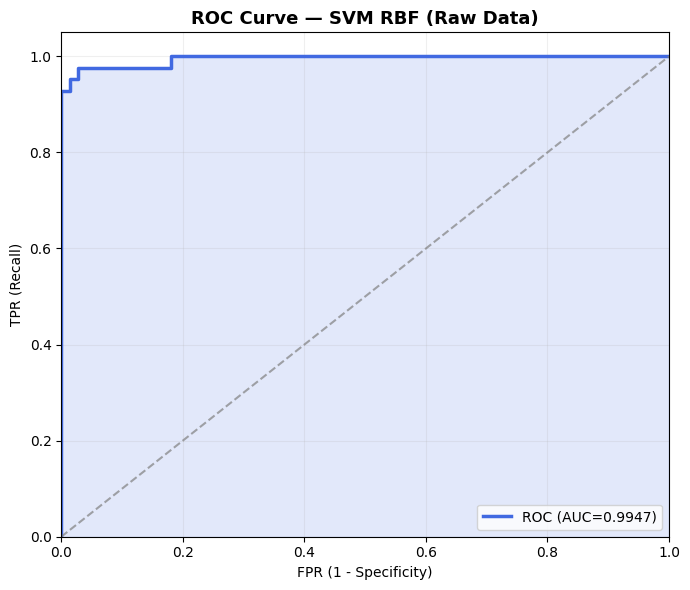

In [8]:
fpr,tpr,_=roc_curve(y_test,y_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,color='royalblue',lw=2.5,label=f'ROC (AUC={auc:.4f})')
plt.fill_between(fpr,tpr,alpha=0.15,color='royalblue')
plt.plot([0,1],[0,1],color='gray',ls='--',alpha=0.7)
plt.xlim(0,1);plt.ylim(0,1.05)
plt.xlabel('FPR (1 - Specificity)');plt.ylabel('TPR (Recall)')
plt.title('ROC Curve — SVM RBF (Raw Data)',fontsize=13,fontweight='bold')
plt.legend();plt.grid(alpha=0.2);plt.tight_layout();plt.show()